# Clean Model Comparison Analysis

This notebook compares selection factors across two DASM models with multiple filtering strategies and aggregation levels.
Here we compare two models that were trained with the same data and parameters. 

## Setup and Imports

In [1]:
from tqdm.auto import tqdm
tqdm.pandas()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, linregress

from utils import load_and_process_dasm_data

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

## Configuration

In [2]:
# Model paths
model_1_name = "../trained_models_no_multihit/dasm_4m-v1jaffeCC+v1tangCC-joint"
model_2_name = "../2026-01-12_retrain_no_mh/dasm_4m-v1jaffeCC+v1tangCC-joint"

# Dataset configuration
dataset_name = "v1rodriguez"
numbering_scheme = 'chothia'

# Analysis parameters
n_pcp_samples = 1000
clip_lower = -4  # Lower bound for log selection factors
figures_dir = 'figures'

## Load Model Data

In [3]:
print(f"Loading Model 1: {model_1_name}")
model1_site_sub_probs_df, model1_pcp_df, model1_selection_df = load_and_process_dasm_data(
    model_name=model_1_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir=figures_dir
)

print(f"\nLoading Model 2: {model_2_name}")
model2_site_sub_probs_df, model2_pcp_df, model2_selection_df = load_and_process_dasm_data(
    model_name=model_2_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir=figures_dir
)

print(f"\nModel 1 selection factors: {len(model1_selection_df):,} rows")
print(f"Model 2 selection factors: {len(model2_selection_df):,} rows")

# Filter out rows where parent_aa == selection_factor_target_aa (these have NA log values)
model1_selection_df = model1_selection_df[model1_selection_df['parent_aa'] != model1_selection_df['selection_factor_target_aa']].copy()
model2_selection_df = model2_selection_df[model2_selection_df['parent_aa'] != model2_selection_df['selection_factor_target_aa']].copy()

print(f"\nAfter filtering parent_aa == target_aa:")
print(f"Model 1: {len(model1_selection_df):,} rows")
print(f"Model 2: {len(model2_selection_df):,} rows")

Loading Model 1: ../trained_models_no_multihit/dasm_4m-v1jaffeCC+v1tangCC-joint
Adding one_mutation_away column (vectorized)...

Loading Model 2: ../2026-01-12_retrain_no_mh/dasm_4m-v1jaffeCC+v1tangCC-joint
Adding one_mutation_away column (vectorized)...

Model 1 selection factors: 52,956,600 rows
Model 2 selection factors: 52,956,600 rows

After filtering parent_aa == target_aa:
Model 1: 50,308,770 rows
Model 2: 50,308,770 rows


## Helper Functions

In [4]:
def plot_regression_comparison(x_data, y_data, title, xlabel, ylabel, clip_lower=-4):
    """
    Create a hexbin plot with regression line, equation, and correlation.
    
    Parameters:
    -----------
    x_data : array-like
        X-axis data (Model 1)
    y_data : array-like
        Y-axis data (Model 2)
    title : str
        Plot title
    xlabel : str
        X-axis label
    ylabel : str
        Y-axis label
    clip_lower : float
        Lower bound for display
    
    Returns:
    --------
    fig : matplotlib figure
    stats : dict with regression statistics
    """
    # Calculate statistics
    r, p_value = pearsonr(x_data, y_data)
    slope, intercept, r_value, p_value_reg, std_err = linregress(x_data, y_data)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Create hexbin plot
    hexbin = ax.hexbin(x_data, y_data, gridsize=50, cmap='Blues', mincnt=1)
    plt.colorbar(hexbin, ax=ax, label='Count')
    
    # Add identity line (y=x)
    lim = [min(x_data.min(), y_data.min()), max(x_data.max(), y_data.max())]
    ax.plot(lim, lim, 'k--', alpha=0.5, linewidth=2, label='y=x')
    
    # Add regression line
    x_reg = np.array(lim)
    y_reg = slope * x_reg + intercept
    ax.plot(x_reg, y_reg, 'r-', linewidth=2, label=f'Regression')
    
    # Add text annotation with equation and correlation
    equation_text = f'y = {slope:.3f}x + {intercept:.3f}\nr = {r:.3f}\np < {p_value:.2e}\nn = {len(x_data):,}'
    ax.text(0.05, 0.95, equation_text, transform=ax.transAxes,
            verticalalignment='top', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    # Labels and title
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    stats = {
        'slope': slope,
        'intercept': intercept,
        'r': r,
        'p_value': p_value,
        'n_points': len(x_data)
    }
    
    return fig, stats

## Part 1: Individual Data Comparisons

Compare selection factors for individual PCP-site-AA combinations using sampled PCPs.

### Sample and Merge Data for Individual Comparisons

In [5]:
# Define merge columns
merge_columns = ['pcp_index', 'site', 'parent_aa', 'selection_factor_target_aa', 'v_family', 'one_mutation_away']

# Sample PCP indices
np.random.seed(42)  # For reproducibility
sampled_pcp_indices = np.random.choice(
    model1_selection_df['pcp_index'].unique(),
    size=min(n_pcp_samples, model1_selection_df['pcp_index'].nunique()),
    replace=False
)

print(f"Sampled {len(sampled_pcp_indices)} PCP indices")

# Select only merge columns + selection factors from each model
model1_cols = merge_columns + ['selection_factor', 'log_selection_factor']
model2_cols = merge_columns + ['selection_factor', 'log_selection_factor']

sampled_model1 = model1_selection_df[model1_selection_df['pcp_index'].isin(sampled_pcp_indices)][model1_cols]
sampled_model2 = model2_selection_df[model2_selection_df['pcp_index'].isin(sampled_pcp_indices)][model2_cols]

# Count before merge
sampled_model1_count = len(sampled_model1)
sampled_model2_count = len(sampled_model2)

# Merge
comparison_df = pd.merge(
    sampled_model1,
    sampled_model2,
    on=merge_columns,
    suffixes=('_model1', '_model2')
)

# Diagnostics
print(f"\nIndividual-level merge diagnostics:")
print(f"Model 1 (sampled 1000 PCPs): {sampled_model1_count:,} rows")
print(f"Model 2 (sampled 1000 PCPs): {sampled_model2_count:,} rows")
print(f"After merge: {len(comparison_df):,} rows")
print(f"Row retention: {len(comparison_df) / sampled_model1_count * 100:.2f}%")
print(f"Merged data columns: {list(comparison_df.columns)}")

Sampled 1000 PCP indices

Individual-level merge diagnostics:
Model 1 (sampled 1000 PCPs): 2,310,666 rows
Model 2 (sampled 1000 PCPs): 2,310,666 rows
After merge: 2,310,666 rows
Row retention: 100.00%
Merged data columns: ['pcp_index', 'site', 'parent_aa', 'selection_factor_target_aa', 'v_family', 'one_mutation_away', 'selection_factor_model1', 'log_selection_factor_model1', 'selection_factor_model2', 'log_selection_factor_model2']


### 1.1: All Data (Clipped at -4)

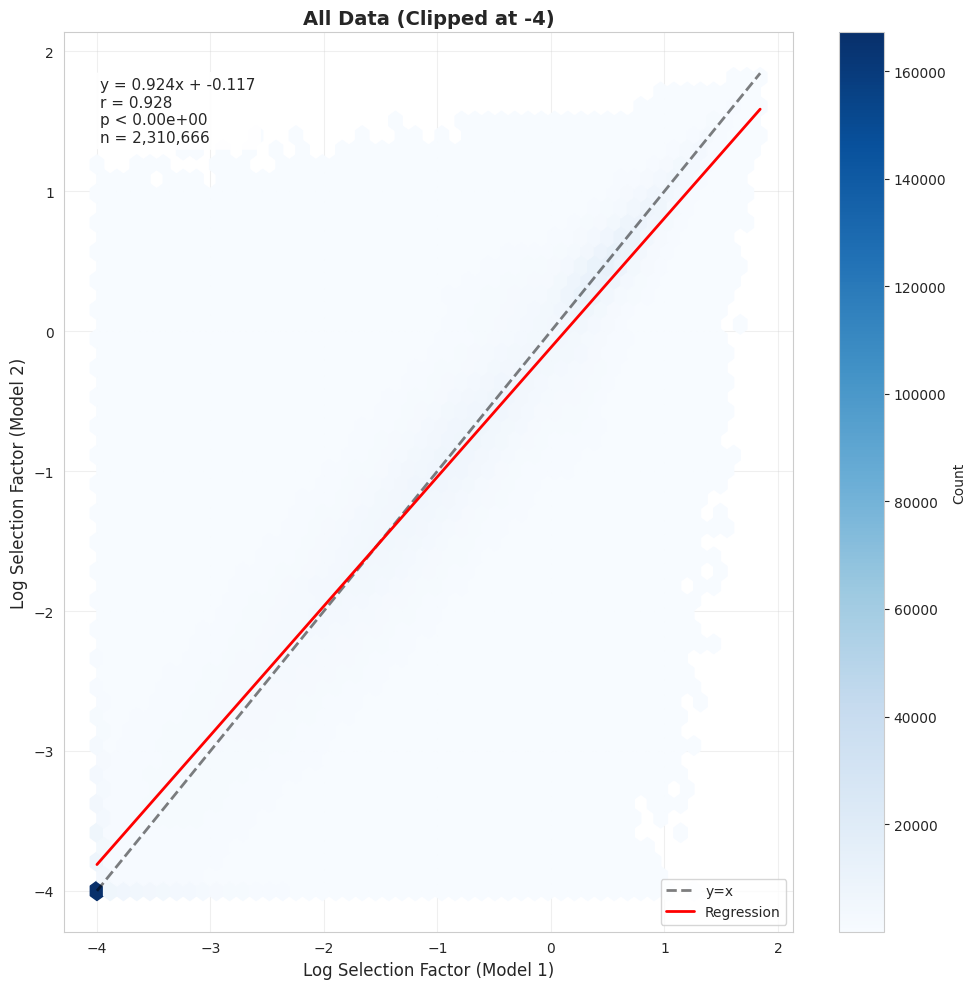


Stats: slope=0.9239, r=0.9283, n=2,310,666


In [6]:
# Clip low values at -4
df_all_clipped = comparison_df.copy()
df_all_clipped['log_sf_model1'] = df_all_clipped['log_selection_factor_model1'].clip(lower=clip_lower)
df_all_clipped['log_sf_model2'] = df_all_clipped['log_selection_factor_model2'].clip(lower=clip_lower)

fig1, stats1 = plot_regression_comparison(
    df_all_clipped['log_sf_model1'],
    df_all_clipped['log_sf_model2'],
    'All Data (Clipped at -4)',
    'Log Selection Factor (Model 1)',
    'Log Selection Factor (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats1['slope']:.4f}, r={stats1['r']:.4f}, n={stats1['n_points']:,}")

### 1.2: Only one_mutation_away=True (Clipped at -4)

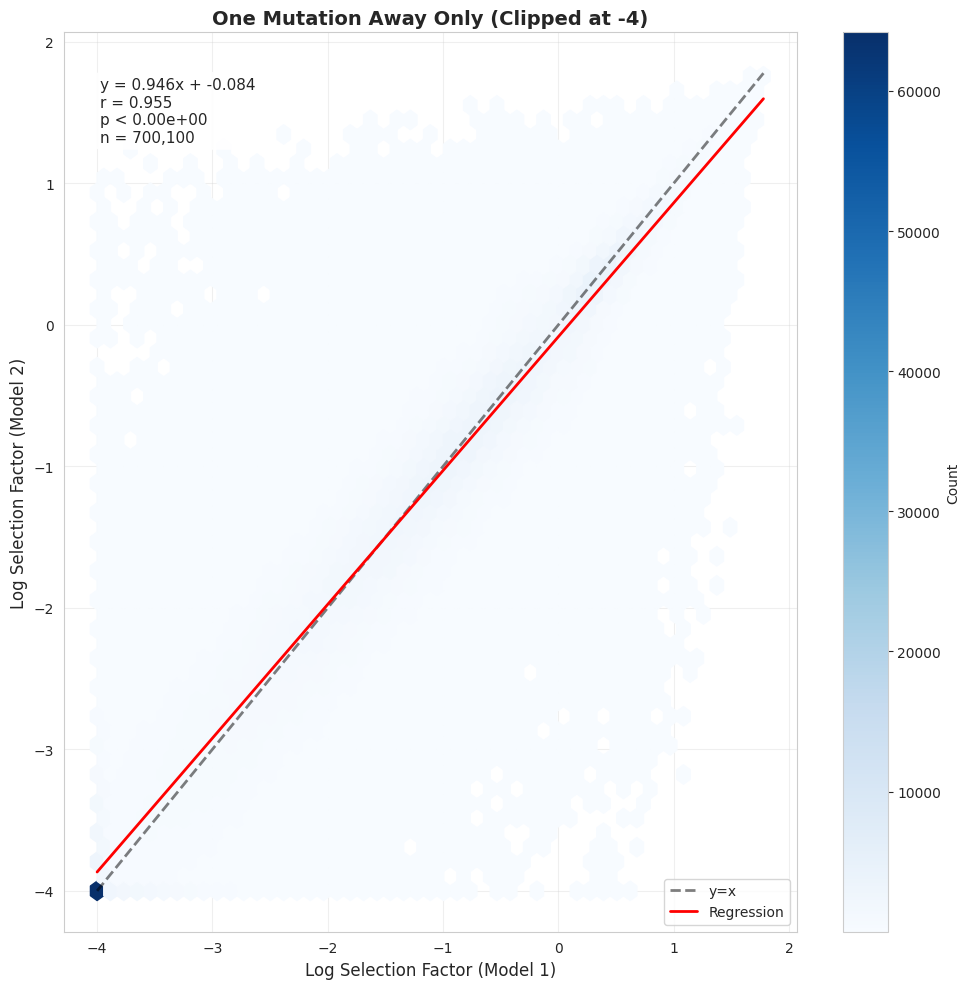


Stats: slope=0.9457, r=0.9549, n=700,100


In [7]:
# Filter to one_mutation_away=True
df_onemut_clipped = comparison_df[comparison_df['one_mutation_away'] == True].copy()
df_onemut_clipped['log_sf_model1'] = df_onemut_clipped['log_selection_factor_model1'].clip(lower=clip_lower)
df_onemut_clipped['log_sf_model2'] = df_onemut_clipped['log_selection_factor_model2'].clip(lower=clip_lower)

fig2, stats2 = plot_regression_comparison(
    df_onemut_clipped['log_sf_model1'],
    df_onemut_clipped['log_sf_model2'],
    'One Mutation Away Only (Clipped at -4)',
    'Log Selection Factor (Model 1)',
    'Log Selection Factor (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats2['slope']:.4f}, r={stats2['r']:.4f}, n={stats2['n_points']:,}")

### 1.3: Filtering Data < -4 on Either Axis

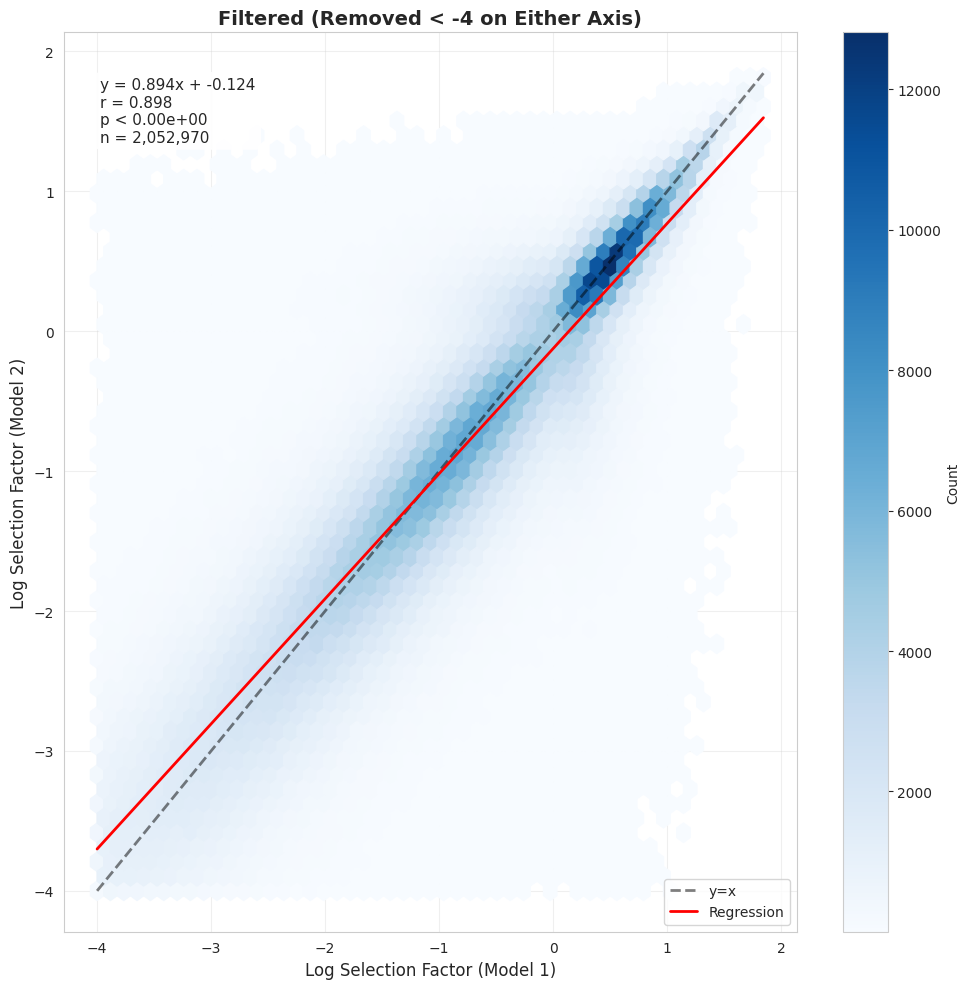


Stats: slope=0.8944, r=0.8976, n=2,052,970
Percentage retained: 88.85%


In [8]:
# Filter out data < -4 on either axis
df_filtered = comparison_df[
    (comparison_df['log_selection_factor_model1'] > clip_lower) &
    (comparison_df['log_selection_factor_model2'] > clip_lower)
].copy()

fig3, stats3 = plot_regression_comparison(
    df_filtered['log_selection_factor_model1'],
    df_filtered['log_selection_factor_model2'],
    'Filtered (Removed < -4 on Either Axis)',
    'Log Selection Factor (Model 1)',
    'Log Selection Factor (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats3['slope']:.4f}, r={stats3['r']:.4f}, n={stats3['n_points']:,}")
print(f"Percentage retained: {len(df_filtered) / len(comparison_df) * 100:.2f}%")

### 1.4: Filtered < -4 + one_mutation_away=True

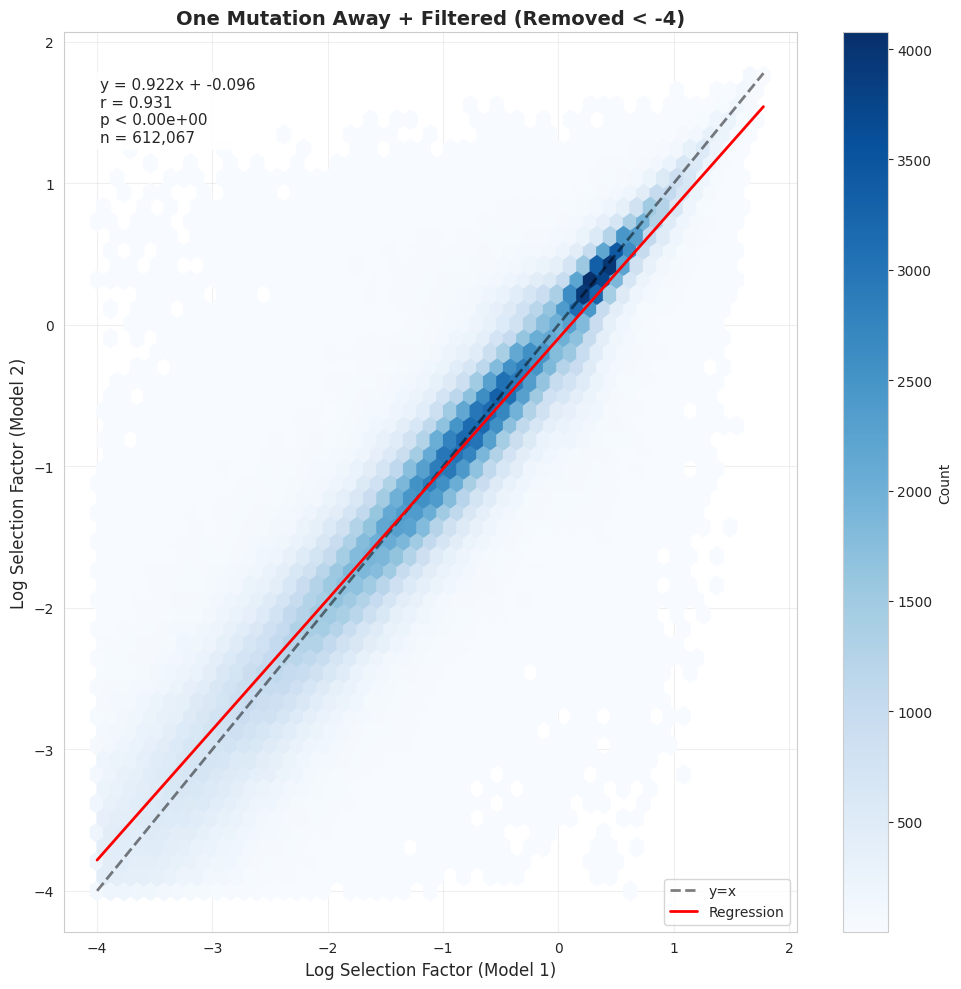


Stats: slope=0.9215, r=0.9314, n=612,067
Percentage retained: 26.49%


In [9]:
# Filter: one_mutation_away=True AND > -4 on both axes
df_filtered_onemut = comparison_df[
    (comparison_df['one_mutation_away'] == True) &
    (comparison_df['log_selection_factor_model1'] > clip_lower) &
    (comparison_df['log_selection_factor_model2'] > clip_lower)
].copy()

fig4, stats4 = plot_regression_comparison(
    df_filtered_onemut['log_selection_factor_model1'],
    df_filtered_onemut['log_selection_factor_model2'],
    'One Mutation Away + Filtered (Removed < -4)',
    'Log Selection Factor (Model 1)',
    'Log Selection Factor (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats4['slope']:.4f}, r={stats4['r']:.4f}, n={stats4['n_points']:,}")
print(f"Percentage retained: {len(df_filtered_onemut) / len(comparison_df) * 100:.2f}%")

## Part 2: Aggregated Data Comparisons

Aggregate ALL data by (v_family, site, parent_aa, selection_factor_target_aa) and compare median selection factors.

Strategy: Aggregate each model separately, then merge the aggregated results.

In [10]:
# Define grouping columns
grouping_cols = ['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']

### 2.1: All Data Aggregated (Clipped at -4)

Aggregation diagnostics (All Data, Clipped):
Model 1 unique contexts: 153,387
Model 2 unique contexts: 153,387
After merge: 153,387 contexts
Context retention: 100.00%


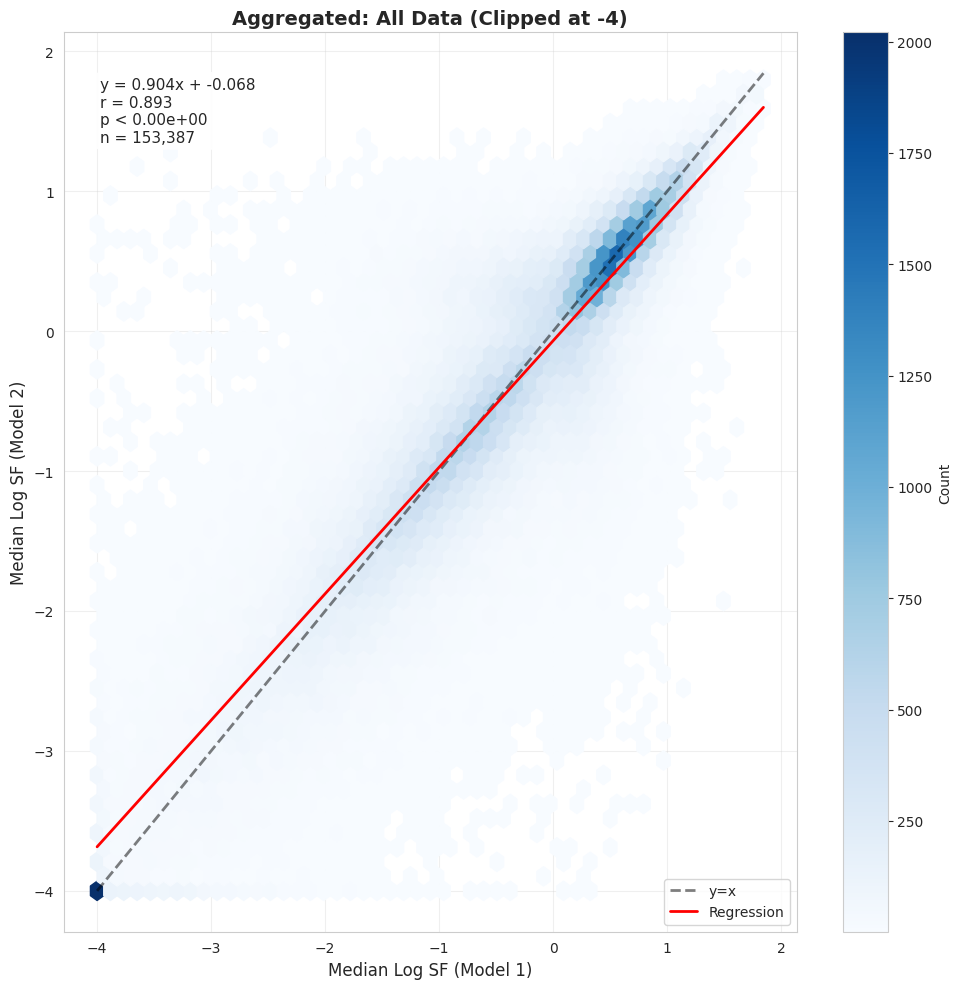


Stats: slope=0.9044, r=0.8930, n=153,387


In [11]:
# Aggregate Model 1 - clip then aggregate
agg_model1 = model1_selection_df.copy()
agg_model1['log_sf_clipped'] = agg_model1['log_selection_factor'].clip(lower=clip_lower)
agg_model1_grouped = agg_model1.groupby(grouping_cols).agg({
    'log_sf_clipped': 'median'
}).reset_index()
agg_model1_grouped.columns = grouping_cols + ['median_log_sf_model1']

# Aggregate Model 2 - clip then aggregate
agg_model2 = model2_selection_df.copy()
agg_model2['log_sf_clipped'] = agg_model2['log_selection_factor'].clip(lower=clip_lower)
agg_model2_grouped = agg_model2.groupby(grouping_cols).agg({
    'log_sf_clipped': 'median'
}).reset_index()
agg_model2_grouped.columns = grouping_cols + ['median_log_sf_model2']

# Diagnostics before merge
print(f"Aggregation diagnostics (All Data, Clipped):")
print(f"Model 1 unique contexts: {len(agg_model1_grouped):,}")
print(f"Model 2 unique contexts: {len(agg_model2_grouped):,}")

# Merge aggregated data
agg_all = pd.merge(agg_model1_grouped, agg_model2_grouped, on=grouping_cols)

# Diagnostics after merge
print(f"After merge: {len(agg_all):,} contexts")
print(f"Context retention: {len(agg_all) / len(agg_model1_grouped) * 100:.2f}%")

fig5, stats5 = plot_regression_comparison(
    agg_all['median_log_sf_model1'],
    agg_all['median_log_sf_model2'],
    'Aggregated: All Data (Clipped at -4)',
    'Median Log SF (Model 1)',
    'Median Log SF (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats5['slope']:.4f}, r={stats5['r']:.4f}, n={stats5['n_points']:,}")

### 2.2: Aggregated one_mutation_away=True (Clipped at -4)

Aggregation diagnostics (One Mutation Away, Clipped):
Model 1 unique contexts: 55,934
Model 2 unique contexts: 55,934
After merge: 55,934 contexts
Context retention: 100.00%


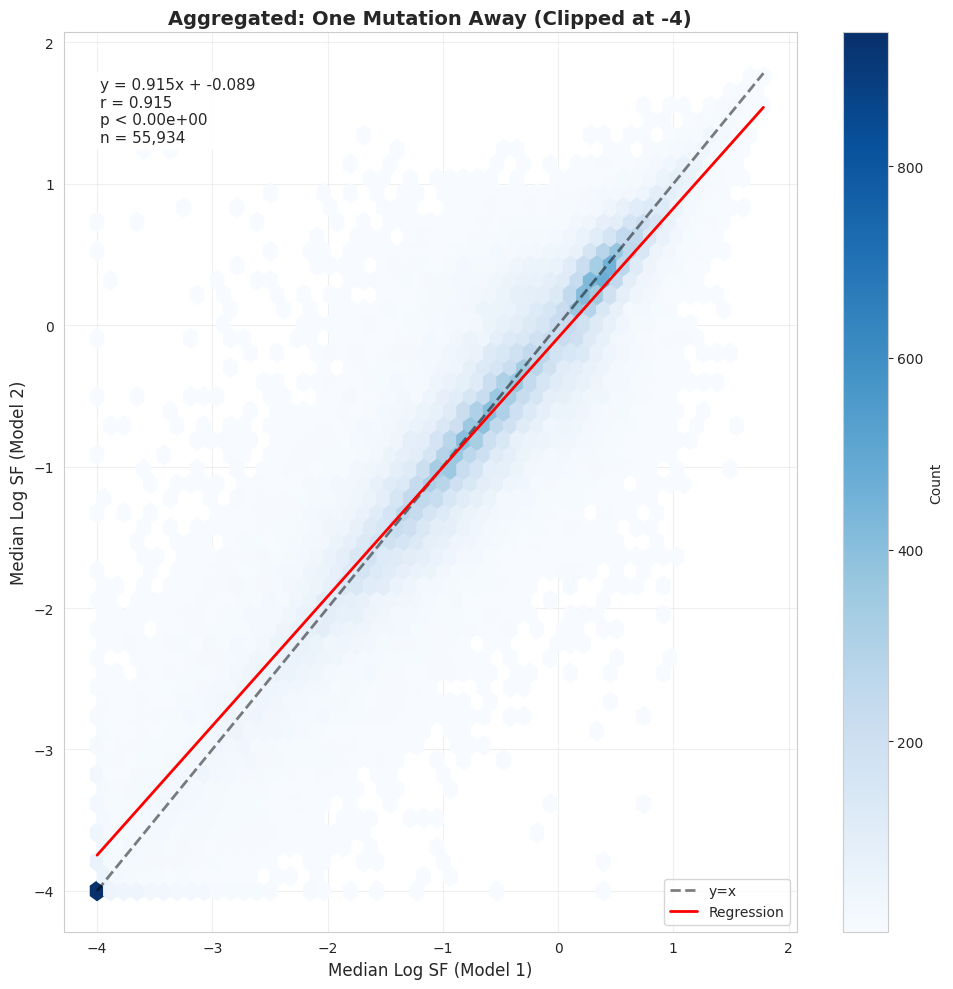


Stats: slope=0.9147, r=0.9146, n=55,934


In [12]:
# Filter to one_mutation_away=True, clip, then aggregate
# Aggregate Model 1
agg_model1_onemut = model1_selection_df[model1_selection_df['one_mutation_away'] == True].copy()
agg_model1_onemut['log_sf_clipped'] = agg_model1_onemut['log_selection_factor'].clip(lower=clip_lower)
agg_model1_onemut_grouped = agg_model1_onemut.groupby(grouping_cols).agg({
    'log_sf_clipped': 'median'
}).reset_index()
agg_model1_onemut_grouped.columns = grouping_cols + ['median_log_sf_model1']

# Aggregate Model 2
agg_model2_onemut = model2_selection_df[model2_selection_df['one_mutation_away'] == True].copy()
agg_model2_onemut['log_sf_clipped'] = agg_model2_onemut['log_selection_factor'].clip(lower=clip_lower)
agg_model2_onemut_grouped = agg_model2_onemut.groupby(grouping_cols).agg({
    'log_sf_clipped': 'median'
}).reset_index()
agg_model2_onemut_grouped.columns = grouping_cols + ['median_log_sf_model2']

# Diagnostics before merge
print(f"Aggregation diagnostics (One Mutation Away, Clipped):")
print(f"Model 1 unique contexts: {len(agg_model1_onemut_grouped):,}")
print(f"Model 2 unique contexts: {len(agg_model2_onemut_grouped):,}")

# Merge aggregated data
agg_onemut = pd.merge(agg_model1_onemut_grouped, agg_model2_onemut_grouped, on=grouping_cols)

# Diagnostics after merge
print(f"After merge: {len(agg_onemut):,} contexts")
print(f"Context retention: {len(agg_onemut) / len(agg_model1_onemut_grouped) * 100:.2f}%")

fig6, stats6 = plot_regression_comparison(
    agg_onemut['median_log_sf_model1'],
    agg_onemut['median_log_sf_model2'],
    'Aggregated: One Mutation Away (Clipped at -4)',
    'Median Log SF (Model 1)',
    'Median Log SF (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats6['slope']:.4f}, r={stats6['r']:.4f}, n={stats6['n_points']:,}")

### 2.3: Aggregated Filtered < -4 on Either Axis

Aggregation diagnostics (Filtered < -4):
Model 1 unique contexts: 152,626
Model 2 unique contexts: 152,453
After merge: 152,154 contexts
Context retention: 99.69%


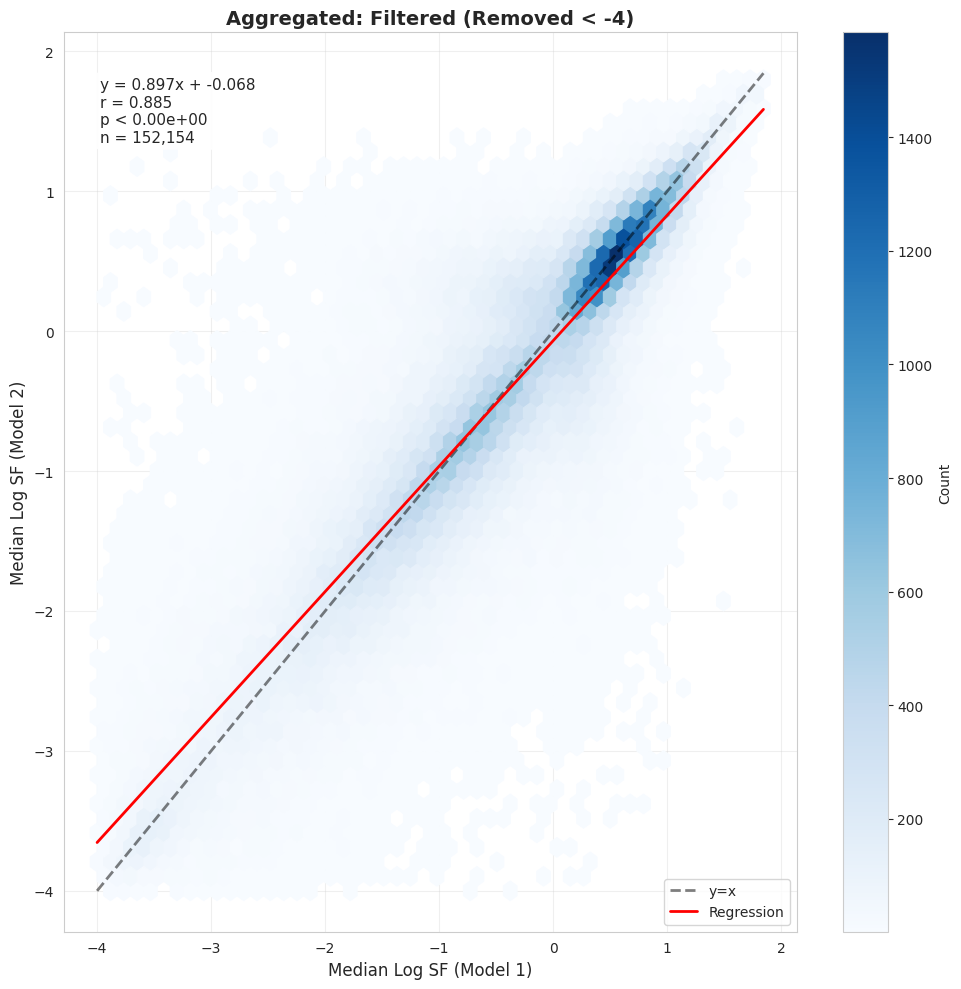


Stats: slope=0.8967, r=0.8849, n=152,154


In [13]:
# Filter out < -4, then aggregate
# Aggregate Model 1
agg_model1_filtered = model1_selection_df[model1_selection_df['log_selection_factor'] > clip_lower].copy()
agg_model1_filtered_grouped = agg_model1_filtered.groupby(grouping_cols).agg({
    'log_selection_factor': 'median'
}).reset_index()
agg_model1_filtered_grouped.columns = grouping_cols + ['median_log_sf_model1']

# Aggregate Model 2
agg_model2_filtered = model2_selection_df[model2_selection_df['log_selection_factor'] > clip_lower].copy()
agg_model2_filtered_grouped = agg_model2_filtered.groupby(grouping_cols).agg({
    'log_selection_factor': 'median'
}).reset_index()
agg_model2_filtered_grouped.columns = grouping_cols + ['median_log_sf_model2']

# Diagnostics before merge
print(f"Aggregation diagnostics (Filtered < -4):")
print(f"Model 1 unique contexts: {len(agg_model1_filtered_grouped):,}")
print(f"Model 2 unique contexts: {len(agg_model2_filtered_grouped):,}")

# Merge aggregated data
agg_filtered = pd.merge(agg_model1_filtered_grouped, agg_model2_filtered_grouped, on=grouping_cols)

# Further filter: only keep rows where both medians are > clip_lower
agg_filtered = agg_filtered[
    (agg_filtered['median_log_sf_model1'] > clip_lower) &
    (agg_filtered['median_log_sf_model2'] > clip_lower)
].copy()

# Diagnostics after merge and post-filter
print(f"After merge: {len(agg_filtered):,} contexts")
print(f"Context retention: {len(agg_filtered) / len(agg_model1_filtered_grouped) * 100:.2f}%")

fig7, stats7 = plot_regression_comparison(
    agg_filtered['median_log_sf_model1'],
    agg_filtered['median_log_sf_model2'],
    'Aggregated: Filtered (Removed < -4)',
    'Median Log SF (Model 1)',
    'Median Log SF (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats7['slope']:.4f}, r={stats7['r']:.4f}, n={stats7['n_points']:,}")

### 2.4: Aggregated Filtered < -4 + one_mutation_away=True

Aggregation diagnostics (One Mutation Away + Filtered < -4):
Model 1 unique contexts: 55,548
Model 2 unique contexts: 55,524
After merge: 55,380 contexts
Context retention: 99.70%


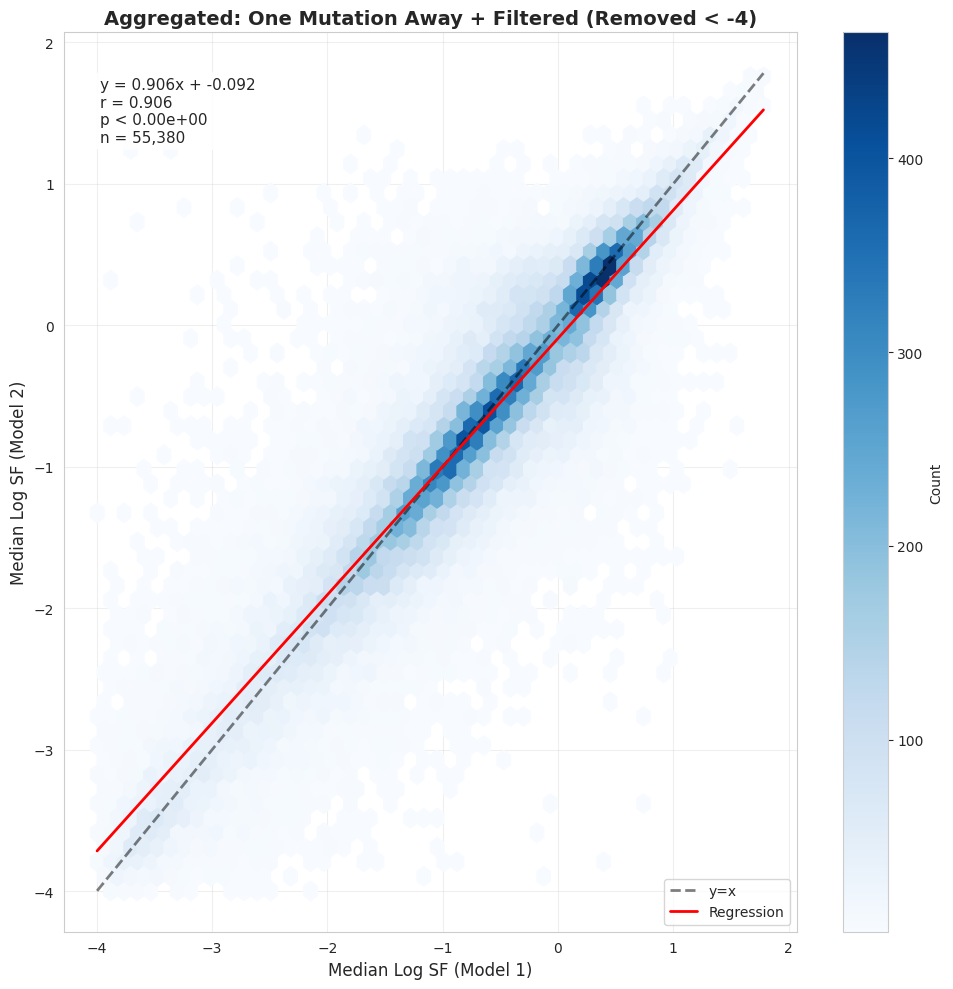


Stats: slope=0.9063, r=0.9056, n=55,380


In [14]:
# Filter: one_mutation_away=True AND > -4, then aggregate
# Aggregate Model 1
agg_model1_filtered_onemut = model1_selection_df[
    (model1_selection_df['one_mutation_away'] == True) &
    (model1_selection_df['log_selection_factor'] > clip_lower)
].copy()
agg_model1_filtered_onemut_grouped = agg_model1_filtered_onemut.groupby(grouping_cols).agg({
    'log_selection_factor': 'median'
}).reset_index()
agg_model1_filtered_onemut_grouped.columns = grouping_cols + ['median_log_sf_model1']

# Aggregate Model 2
agg_model2_filtered_onemut = model2_selection_df[
    (model2_selection_df['one_mutation_away'] == True) &
    (model2_selection_df['log_selection_factor'] > clip_lower)
].copy()
agg_model2_filtered_onemut_grouped = agg_model2_filtered_onemut.groupby(grouping_cols).agg({
    'log_selection_factor': 'median'
}).reset_index()
agg_model2_filtered_onemut_grouped.columns = grouping_cols + ['median_log_sf_model2']

# Diagnostics before merge
print(f"Aggregation diagnostics (One Mutation Away + Filtered < -4):")
print(f"Model 1 unique contexts: {len(agg_model1_filtered_onemut_grouped):,}")
print(f"Model 2 unique contexts: {len(agg_model2_filtered_onemut_grouped):,}")

# Merge aggregated data
agg_filtered_onemut = pd.merge(agg_model1_filtered_onemut_grouped, agg_model2_filtered_onemut_grouped, on=grouping_cols)

# Further filter: only keep rows where both medians are > clip_lower
agg_filtered_onemut = agg_filtered_onemut[
    (agg_filtered_onemut['median_log_sf_model1'] > clip_lower) &
    (agg_filtered_onemut['median_log_sf_model2'] > clip_lower)
].copy()

# Diagnostics after merge and post-filter
print(f"After merge: {len(agg_filtered_onemut):,} contexts")
print(f"Context retention: {len(agg_filtered_onemut) / len(agg_model1_filtered_onemut_grouped) * 100:.2f}%")

fig8, stats8 = plot_regression_comparison(
    agg_filtered_onemut['median_log_sf_model1'],
    agg_filtered_onemut['median_log_sf_model2'],
    'Aggregated: One Mutation Away + Filtered (Removed < -4)',
    'Median Log SF (Model 1)',
    'Median Log SF (Model 2)',
    clip_lower=clip_lower
)

plt.show()
print(f"\nStats: slope={stats8['slope']:.4f}, r={stats8['r']:.4f}, n={stats8['n_points']:,}")

## Part 3: Branch Length Comparison

In [15]:
from dnsmex.local import localify

# Load branch lengths
branch_length_1_path = localify(f"DASM_TRAINED_MODELS_DIR/{model_1_name}.train_branch_lengths.csv")
branch_length_2_path = localify(f"DASM_TRAINED_MODELS_DIR/{model_2_name}.train_branch_lengths.csv")

print(f"Loading branch lengths from:")
print(f"  Model 1: {branch_length_1_path}")
print(f"  Model 2: {branch_length_2_path}")

branch_length_1 = pd.read_csv(branch_length_1_path)
branch_length_2 = pd.read_csv(branch_length_2_path)

# Merge on index
branch_comparison = pd.merge(
    branch_length_1.reset_index(),
    branch_length_2.reset_index(),
    on='index',
    suffixes=('_model1', '_model2')
)

print(f"\nBranch lengths loaded: {len(branch_comparison):,} sequences")

Loading branch lengths from:
  Model 1: /home/nharel/re/dnsm-experiments-1/dasm-train/trained_models/../trained_models_no_multihit/dasm_4m-v1jaffeCC+v1tangCC-joint.train_branch_lengths.csv
  Model 2: /home/nharel/re/dnsm-experiments-1/dasm-train/trained_models/../2026-01-12_retrain_no_mh/dasm_4m-v1jaffeCC+v1tangCC-joint.train_branch_lengths.csv

Branch lengths loaded: 742,377 sequences


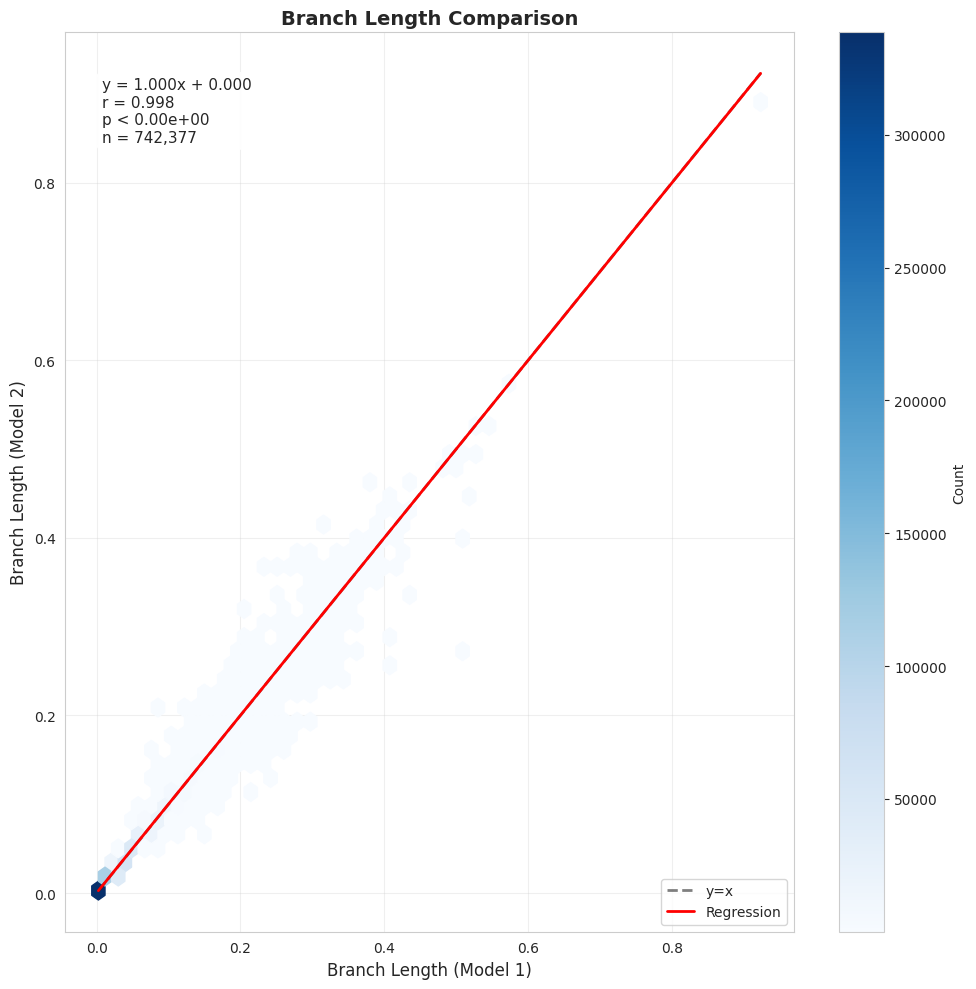


Stats: slope=0.9996, r=0.9979, n=742,377


In [16]:
# Plot branch length comparison
fig9, stats9 = plot_regression_comparison(
    branch_comparison['branch_length_model1'],
    branch_comparison['branch_length_model2'],
    'Branch Length Comparison',
    'Branch Length (Model 1)',
    'Branch Length (Model 2)',
    clip_lower=None
)

plt.show()
print(f"\nStats: slope={stats9['slope']:.4f}, r={stats9['r']:.4f}, n={stats9['n_points']:,}")

## Summary Statistics

In [17]:
# Create summary table
summary_data = [
    {'Analysis': '1. All Data (Clipped)', 'Type': 'Individual', 'Slope': stats1['slope'], 'R': stats1['r'], 'N': stats1['n_points']},
    {'Analysis': '2. One Mut Away (Clipped)', 'Type': 'Individual', 'Slope': stats2['slope'], 'R': stats2['r'], 'N': stats2['n_points']},
    {'Analysis': '3. Filtered < -4', 'Type': 'Individual', 'Slope': stats3['slope'], 'R': stats3['r'], 'N': stats3['n_points']},
    {'Analysis': '4. Filtered + One Mut', 'Type': 'Individual', 'Slope': stats4['slope'], 'R': stats4['r'], 'N': stats4['n_points']},
    {'Analysis': '5. All Data (Clipped)', 'Type': 'Aggregated', 'Slope': stats5['slope'], 'R': stats5['r'], 'N': stats5['n_points']},
    {'Analysis': '6. One Mut Away (Clipped)', 'Type': 'Aggregated', 'Slope': stats6['slope'], 'R': stats6['r'], 'N': stats6['n_points']},
    {'Analysis': '7. Filtered < -4', 'Type': 'Aggregated', 'Slope': stats7['slope'], 'R': stats7['r'], 'N': stats7['n_points']},
    {'Analysis': '8. Filtered + One Mut', 'Type': 'Aggregated', 'Slope': stats8['slope'], 'R': stats8['r'], 'N': stats8['n_points']},
    {'Analysis': '9. Branch Lengths', 'Type': 'Branch', 'Slope': stats9['slope'], 'R': stats9['r'], 'N': stats9['n_points']},
]

summary_df = pd.DataFrame(summary_data)
summary_df['Slope'] = summary_df['Slope'].round(4)
summary_df['R'] = summary_df['R'].round(4)

print("\n" + "="*80)
print("SUMMARY OF ALL COMPARISONS")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


SUMMARY OF ALL COMPARISONS
                 Analysis       Type  Slope      R       N
    1. All Data (Clipped) Individual 0.9239 0.9283 2310666
2. One Mut Away (Clipped) Individual 0.9457 0.9549  700100
         3. Filtered < -4 Individual 0.8944 0.8976 2052970
    4. Filtered + One Mut Individual 0.9215 0.9314  612067
    5. All Data (Clipped) Aggregated 0.9044 0.8930  153387
6. One Mut Away (Clipped) Aggregated 0.9147 0.9146   55934
         7. Filtered < -4 Aggregated 0.8967 0.8849  152154
    8. Filtered + One Mut Aggregated 0.9063 0.9056   55380
        9. Branch Lengths     Branch 0.9996 0.9979  742377
